In [ ]:
import numpy as np
import pandas as pd
from PyEMD import EMD, EEMD, CEEMDAN
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import median_abs_deviation
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import yfinance as yf

def get_valid_segment(s):
    """Extract valid (non-NaN) segment from series"""
    valid = s.dropna()
    if len(valid) < 10:
        return None, None, None
    
    start, end = valid.index[0], valid.index[-1]
    return start, end, s.loc[start:end]

def calculate_imf_distance_matrix(imfs, metric='euclidean'):
    """
    Calculate pairwise distances between IMFs
    
    Parameters:
    -----------
    imfs : array-like, shape (n_imfs, n_samples)
        The IMF components
    metric : str
        Distance metric: 'euclidean', 'chebyshev', 'minkowski', 'correlation'
    
    Returns:
    --------
    distance_matrix : ndarray, shape (n_imfs, n_imfs)
        Pairwise distance matrix
    """
    if metric == 'correlation':
        # Use correlation-based distance
        corr_matrix = np.corrcoef(imfs)
        distance_matrix = 1 - np.abs(corr_matrix)  # Convert correlation to distance
    else:
        # Use scipy's pdist for other metrics
        condensed_dist = pdist(imfs, metric=metric)
        distance_matrix = squareform(condensed_dist)
    
    return distance_matrix

def hierarchical_clustering_imfs(imfs, n_clusters=3, metric='euclidean', 
                                  linkage_method='ward', plot_dendrogram=False):
    """
    Perform hierarchical clustering on IMFs
    
    Parameters:
    -----------
    imfs : array-like, shape (n_imfs, n_samples)
        The IMF components
    n_clusters : int
        Number of final clusters (typically 3: high, low, trend)
    metric : str
        Distance metric for clustering
    linkage_method : str
        Linkage method: 'ward', 'complete', 'average', 'single'
    plot_dendrogram : bool
        Whether to plot the dendrogram
    
    Returns:
    --------
    labels : ndarray
        Cluster labels for each IMF
    linkage_matrix : ndarray
        Hierarchical clustering linkage matrix
    """
    # Calculate distance matrix
    distance_matrix = calculate_imf_distance_matrix(imfs, metric=metric)
    
    # Perform hierarchical clustering
    # Convert to condensed distance matrix for linkage
    condensed_dist = squareform(distance_matrix)
    linkage_matrix = linkage(condensed_dist, method=linkage_method)
    
    # Cut the dendrogram to get n_clusters
    labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    
    # Plot dendrogram if requested
    if plot_dendrogram:
        plt.figure(figsize=(10, 6))
        dendrogram(linkage_matrix)
        plt.title('IMF Hierarchical Clustering Dendrogram')
        plt.xlabel('IMF Index')
        plt.ylabel('Distance')
        plt.axhline(y=linkage_matrix[-n_clusters+1, 2], c='red', linestyle='--', 
                   label=f'{n_clusters} clusters')
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    return labels, linkage_matrix

def assign_frequency_bands(labels, imfs):
    """
    Assign clusters to high/medium/low frequency based on average frequency
    
    IMFs from EMD are ordered from high to low frequency, so:
    - Lower indices = higher frequency
    - Higher indices = lower frequency (trend)
    """
    n_clusters = len(np.unique(labels))
    cluster_avg_index = {}
    
    # Calculate average IMF index for each cluster
    for cluster_id in np.unique(labels):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_avg_index[cluster_id] = np.mean(cluster_indices)
    
    # Sort clusters by average index (low index = high freq)
    sorted_clusters = sorted(cluster_avg_index.items(), key=lambda x: x[1])
    
    # Assign to frequency bands
    cluster_mapping = {}
    if n_clusters == 3:
        cluster_mapping[sorted_clusters[0][0]] = 'high'    # Lowest avg index
        cluster_mapping[sorted_clusters[1][0]] = 'medium'  # Middle avg index
        cluster_mapping[sorted_clusters[2][0]] = 'low'     # Highest avg index (trend)
    elif n_clusters == 2:
        cluster_mapping[sorted_clusters[0][0]] = 'high'
        cluster_mapping[sorted_clusters[1][0]] = 'low'
    else:
        # For other numbers of clusters, distribute evenly
        for i, (cluster_id, _) in enumerate(sorted_clusters):
            if i < n_clusters // 3:
                cluster_mapping[cluster_id] = 'high'
            elif i < 2 * n_clusters // 3:
                cluster_mapping[cluster_id] = 'medium'
            else:
                cluster_mapping[cluster_id] = 'low'
    
    return cluster_mapping

def emd_hierarchical_clustering(data, n_clusters=3, metric='euclidean', 
                                linkage_method='ward', plot_dendrograms=False):
    """
    Decompose time series using EMD + Hierarchical Clustering
    
    Parameters:
    -----------
    data : DataFrame
        Time series data (index: dates, columns: asset names)
    n_clusters : int
        Number of clusters (typically 3)
    metric : str
        Distance metric: 'euclidean', 'chebyshev', 'minkowski', 'correlation'
    linkage_method : str
        Hierarchical clustering linkage method
    plot_dendrograms : bool
        Whether to plot dendrograms for each series
    
    Returns:
    --------
    high_freq : DataFrame
        High frequency components
    medium_freq : DataFrame
        Medium frequency components (if n_clusters >= 3)
    low_freq : DataFrame
        Low frequency/trend components
    """
    high, medium, low = {}, {}, {}
    emd = EMD()

    for col in tqdm(data.columns, desc="Processing series"):
        s = data[col]
        
        start, end, seg = get_valid_segment(s)
        if seg is None:
            continue

        # Interpolate and clean data
        x = seg.interpolate(limit_area="inside").values
        x_clean = x.copy()
        
        # Handle remaining NaNs
        if np.isnan(x_clean).any():
            x_clean = pd.Series(x_clean).bfill().ffill().values
        
        t = np.arange(len(x_clean))

        # Perform EMD
        try:
            imfs = emd.emd(x_clean, t)
        except Exception as e:
            print(f"EMD failed for {col}: {e}")
            continue

        if len(imfs) < 2:
            continue

        # Hierarchical clustering of IMFs
        try:
            labels, linkage_matrix = hierarchical_clustering_imfs(
                imfs, 
                n_clusters=min(n_clusters, len(imfs)),
                metric=metric,
                linkage_method=linkage_method,
                plot_dendrogram=plot_dendrograms
            )
        except Exception as e:
            print(f"Clustering failed for {col}: {e}")
            continue
        
        # Assign frequency bands
        cluster_mapping = assign_frequency_bands(labels, imfs)
        
        # Aggregate IMFs by cluster
        high_components = []
        medium_components = []
        low_components = []
        
        for i, imf in enumerate(imfs):
            freq_band = cluster_mapping.get(labels[i], 'medium')
            if freq_band == 'high':
                high_components.append(imf)
            elif freq_band == 'medium':
                medium_components.append(imf)
            else:  # 'low'
                low_components.append(imf)
        
        # Sum components in each band
        h = np.sum(high_components, axis=0) if high_components else np.zeros(len(x_clean))
        m = np.sum(medium_components, axis=0) if medium_components else np.zeros(len(x_clean))
        l = np.sum(low_components, axis=0) if low_components else np.zeros(len(x_clean))
        
        # Create full-length series
        h_full = pd.Series(np.nan, index=data.index)
        m_full = pd.Series(np.nan, index=data.index)
        l_full = pd.Series(np.nan, index=data.index)

        h_full.loc[start:end] = h
        m_full.loc[start:end] = m
        l_full.loc[start:end] = l

        high[col] = h_full
        medium[col] = m_full
        low[col] = l_full

    return (
        pd.DataFrame(high),
        pd.DataFrame(medium),
        pd.DataFrame(low),
    )


# Example usage:
if __name__ == "__main__":

    years = [2019, 2020, 2021, 2022, 2023, 2024]
    base_path = "../../data/02_clean"
    emd_results = {}

    # returns = pd.read_parquet("../../data/02_clean/returns_2019.parquet")
    # cols = returns.loc[:, ~returns.isna().any()].columns

    # year = 2019
    # data_temp = yf.download(tickers=list(cols), start=f"{year-4}-01-01", end=f"{year}-12-31")["Close"].pct_change()[1:]
    # cols = data_temp.loc[:, ~data_temp.isna().any()].columns
    
    for year in years:
        print(f"Processing {year}...")

        returns = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")
        log_returns = np.log(1 + returns)

        fast_emd, medium_emd, slow_emd = emd_hierarchical_clustering(data=log_returns,
                                                                        n_clusters=3,
                                                                        metric="euclidean",
                                                                        linkage_method="ward")

        emd_results[f"{year}"] = {
            "fast": fast_emd,
            "medium": medium_emd,
            "slow": slow_emd,
        }

    # Save
    base_out = "../../data/03_modes"

    for year, modes in emd_results.items():
        year_path = f"{base_out}/{year}"
        os.makedirs(year_path, exist_ok=True)

        emd_results[f"{year}"]["fast"].to_parquet(f"{year_path}/fast_emd.parquet")
        emd_results[f"{year}"]["medium"].to_parquet(f"{year_path}/medium_emd.parquet")
        emd_results[f"{year}"]["slow"].to_parquet(f"{year_path}/slow_emd.parquet")

        print(f"Saved EMD modes for {year}")

Processing 2019...


Processing series: 100%|██████████| 406/406 [00:25<00:00, 16.16it/s]


Processing 2020...


Processing series: 100%|██████████| 406/406 [00:25<00:00, 16.16it/s]


Processing 2021...


...

Processing 2023...


Processing series: 100%|██████████| 406/406 [00:23<00:00, 16.96it/s]


Processing 2024...


Processing series: 100%|██████████| 406/406 [00:25<00:00, 16.22it/s]


Saved EMD modes for 2019
Saved EMD modes for 2020
Saved EMD modes for 2021
Saved EMD modes for 2022
Saved EMD modes for 2023
Saved EMD modes for 2024


In [18]:
year = 2024
returns = pd.read_parquet(f"../../data/02_clean/returns_{year-4}_{year}.parquet")
returns

Ticker,AACG,AAOI,AAPL,ABVC,ACB,ACGL,ACIC,ACIW,ACNT,ACTG,...,WYNN,XENE,XOMA,XRAY,XWIN,XXII,ZBRA,ZTEK,ZUMZ,ZYXI
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.059574,-0.012975,-0.028171,0.000000,0.000000,-0.005984,0.003779,-0.022831,0.000566,-0.003589,...,-0.017020,0.024064,0.090141,-0.006932,0.000000,-0.051429,-0.014077,0.000000,0.019105,-0.111669
2015-01-06,0.020362,-0.037559,0.000094,0.000000,0.000000,0.002236,-0.004706,-0.016096,-0.021493,-0.004202,...,-0.021331,-0.016188,-0.093023,-0.012410,-0.033003,-0.048193,-0.007205,-0.007576,-0.012327,0.000000
2015-01-07,-0.035477,-0.039024,0.014022,0.000000,0.000000,0.005835,-0.006146,0.004222,-0.017341,0.004822,...,0.029368,0.109342,0.042735,0.025918,0.010239,-0.018987,0.025465,-0.022901,0.047322,-0.062540
2015-01-08,-0.027586,0.011167,0.038423,0.000000,0.000000,0.017403,0.034729,-0.001051,-0.001177,-0.009598,...,0.012031,0.100478,0.019126,0.024689,-0.003378,0.012903,0.021359,0.015625,0.027805,0.000000
2015-01-09,0.014184,0.015060,0.001072,0.000000,0.000000,-0.008721,-0.003219,-0.017359,0.017079,-0.006663,...,0.012499,-0.049130,-0.018767,-0.014569,-0.003390,-0.031847,0.014613,-0.076923,-0.042512,-0.020011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-23,-0.013245,0.002698,0.016318,-0.018519,-0.106667,-0.014061,-0.035994,-0.004227,-0.011737,-0.033333,...,0.015791,0.023739,0.133878,0.005805,-0.145000,0.000000,0.016793,-0.035714,0.014752,0.045872
2019-12-24,-0.040268,-0.002691,0.000951,-0.018868,-0.009950,-0.001426,0.008117,-0.007694,0.008709,0.022989,...,-0.005633,0.010870,0.020878,0.000525,-0.005848,0.090000,-0.009348,0.037037,-0.001856,0.021303
2019-12-26,0.027972,0.044065,0.019840,0.000000,0.005025,0.004047,-0.010467,0.010963,0.023548,0.003745,...,0.010757,-0.014337,0.010578,-0.010156,0.011765,0.027523,0.000354,0.071429,0.026960,-0.013497


In [ ]:
base_returns = pd.read_parquet("../../data/02_clean/returns_2019.parquet")
base_cols = base_returns.loc[:, ~base_returns.isna().any()].columns.tolist()

710

In [54]:
import pandas as pd
import yfinance as yf

# Load base universe from clean returns
base_returns = pd.read_parquet("../../data/02_clean/returns_2019.parquet")
base_cols = base_returns.loc[:, ~base_returns.isna().any()].columns.tolist()
year = 2019
prices = yf.download(
        tickers=base_cols,
        start=f"{year-9}-01-01",
        end=f"{year}-12-31",
        auto_adjust=True,
        progress=True
    )["Close"]
returns = prices.pct_change().iloc[1:]
cols = returns.loc[:, ~returns.isna().any()].columns.tolist()
returns = returns[cols]
returns.to_parquet(
        f"../../data/02_clean/returns_{year-9}_{year}.parquet"
    )

for year in range(2020, 2025):
    print(f"Processing {year}...")

    prices = yf.download(
        tickers=cols,
        start=f"{year-9}-01-01",
        end=f"{year}-12-31",
        auto_adjust=True,
        progress=True
    )["Close"]

    returns = prices.pct_change().iloc[1:]

    # Keep only assets with full data in this window
    returns = returns[cols]

    returns.to_parquet(
        f"../../data/02_clean/returns_{year-9}_{year}.parquet"
    )

[*********************100%***********************]  710 of 710 completed


Processing 2020...


[*********************100%***********************]  406 of 406 completed

1 Failed download:
['PLXS']: TypeError("'NoneType' object is not subscriptable")
C:\Users\groque\AppData\Local\Temp\ipykernel_7708\937677909.py:33: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().iloc[1:]


Processing 2021...


[*********************100%***********************]  406 of 406 completed


...

[*********************100%***********************]  406 of 406 completed

1 Failed download:
['AZN']: TypeError("'NoneType' object is not subscriptable")
C:\Users\groque\AppData\Local\Temp\ipykernel_7708\937677909.py:33: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().iloc[1:]


Processing 2023...


[*********************100%***********************]  406 of 406 completed


Processing 2024...


[*********************100%***********************]  406 of 406 completed

1 Failed download:
['TATT']: TypeError("'NoneType' object is not subscriptable")
C:\Users\groque\AppData\Local\Temp\ipykernel_7708\937677909.py:33: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().iloc[1:]


In [10]:
emd_results = {}

fast, medium, slow = emd_hierarchical_clustering(returns)

emd_results['2019'] = {
    "fast": fast,
    "medium": medium,
    "slow": slow,
}

Processing series: 100%|██████████| 546/546 [00:18<00:00, 28.94it/s]


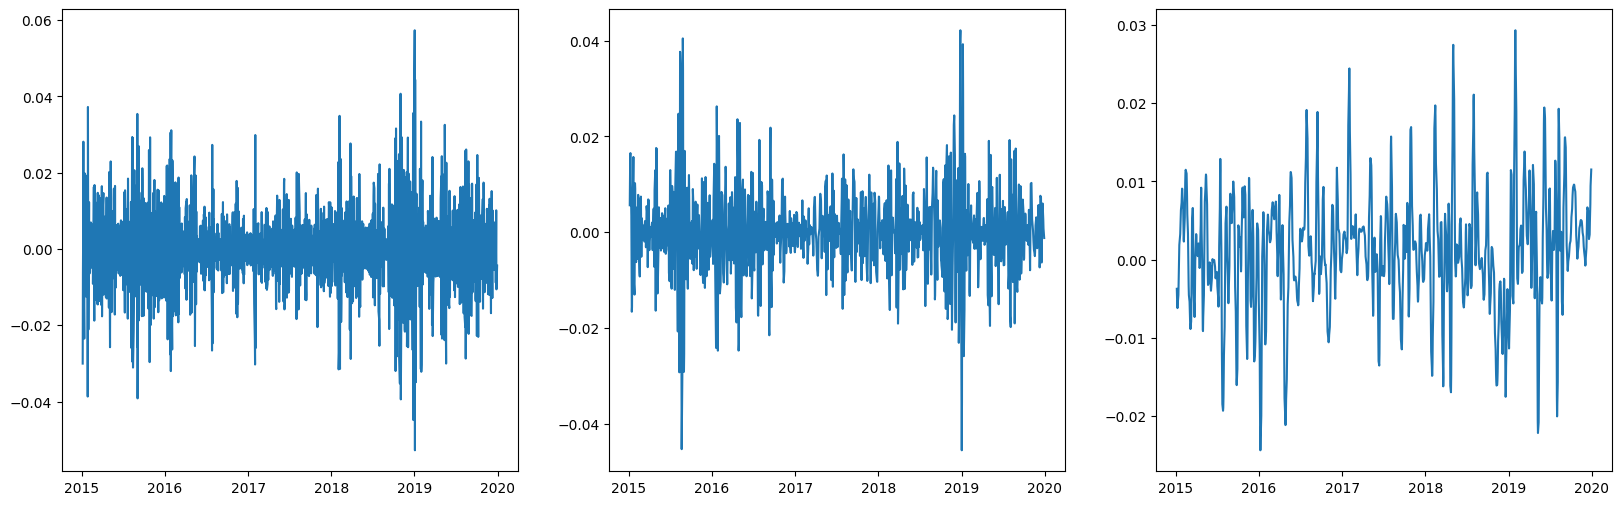

In [12]:
fig, ax = plt.subplots(1,3, figsize=(20,6))

ax[0].plot(emd_results['2019']["fast"]["AAPL"])
ax[1].plot(emd_results['2019']["medium"]["AAPL"])
ax[2].plot(emd_results['2019']["slow"]["AAPL"])

In [13]:
from sklearn.covariance import LedoitWolf

def corr_matrix(mode, min_obs=50, min_assets_frac=0.7):
    """
    Compute absolute correlation matrix using a dense
    subpanel of the mode.
    
    Returns both correlation matrix and asset names.
    """
    n_assets = mode.shape[1]

    # Keep dates with enough assets
    valid_rows = mode.notna().sum(axis=1) >= int(min_assets_frac * n_assets)
    X = mode.loc[valid_rows]

    # Keep assets with enough observations
    valid_cols = X.notna().sum(axis=0) >= min_obs
    X = X.loc[:, valid_cols]

    # Drop remaining NaNs (small)
    X = X.dropna(axis=0, how="any")

    if X.shape[0] < min_obs or X.shape[1] < 5:
        raise ValueError("Panel too sparse to compute correlation.")

    lw = LedoitWolf().fit(X.values)
    cov = lw.covariance_

    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)

    # Retorna matriz de correlação e nomes dos ativos
    return pd.DataFrame(corr, index=X.columns, columns=X.columns)

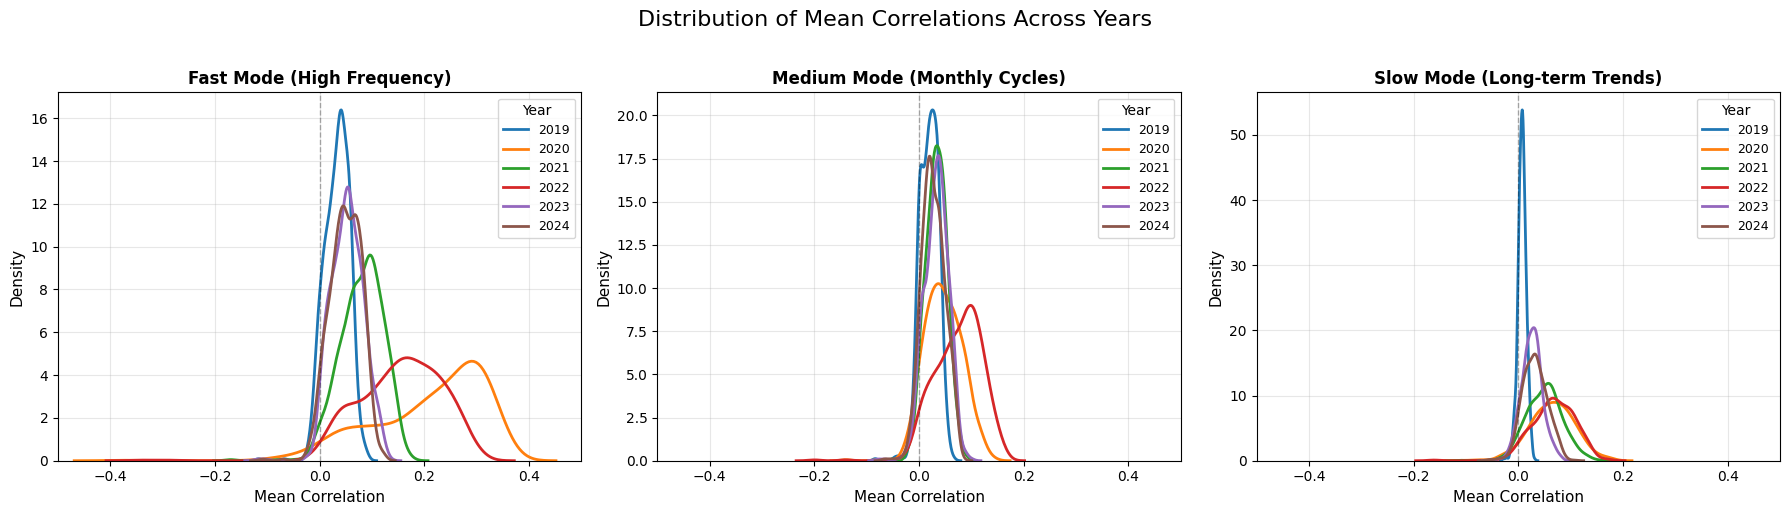

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

years = range(2019, 2025)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Mean Correlations Across Years', fontsize=16, y=1.02)

mode_names = ['fast', 'medium', 'slow']
mode_titles = ['Fast Mode (High Frequency)', 'Medium Mode (Monthly Cycles)', 'Slow Mode (Long-term Trends)']

for mode_idx, mode_name in enumerate(mode_names):
    ax = axes[mode_idx]
    
    for year in years:
        try:
            # Compute correlation matrix
            mode_returns = emd_results[year][mode_name].diff()
            # mode_returns = mode_returns[mode_returns.index > f"{year}-01-01"]
            corr = corr_matrix(mode_returns)
            
            # CRITICAL FIX: Extract only correlation values, excluding diagonal
            corr_values = corr.values.copy()  # Get numpy array
            np.fill_diagonal(corr_values, np.nan)  # Remove self-correlations
            
            # Get mean correlation per asset (excluding self)
            mean_corr_per_asset = np.nanmean(corr_values, axis=0)
            
            # ALTERNATIVE: Get all pairwise correlations (upper triangle)
            # mask = np.triu(np.ones_like(corr_values), k=1).astype(bool)
            # all_correlations = corr_values[mask]
            
            # Plot KDE
            sns.kdeplot(mean_corr_per_asset, ax=ax, label=str(year), linewidth=2)
            
        except Exception as e:
            print(f"Warning: {mode_name} {year}: {e}")
            continue
    
    ax.set_xlabel('Mean Correlation', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(mode_titles[mode_idx], fontsize=12, fontweight='bold')
    ax.legend(title='Year', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(0, color='black', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_xlim(-0.5, 0.5)  # Correlations must be in [-1, 1]

plt.tight_layout()
plt.show()